# EDA
Analysed raw data of sales history and products along with demand by seasonality, holiday and region

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sales = pd.read_csv(
    "../data/raw/sales_history.csv",
    parse_dates=["date"]
)

sales.head()

,date,sku,product,pack_size,region,units_sold,price,promotion,is_holiday
0,2023-01-01,BB250,Bharat Cola,250ml,North,464,24.0,0,0
1,2023-01-01,BB250,Bharat Cola,250ml,South,623,24.0,0,0
2,2023-01-01,BB250,Bharat Cola,250ml,East,428,24.0,0,0
3,2023-01-01,BB250,Bharat Cola,250ml,West,576,24.0,0,0
4,2023-01-01,BB250,Bharat Cola,250ml,Central,426,24.0,0,0


In [2]:
print("Shape:", sales.shape)

print("\nColumns:")
print(sales.columns.tolist())

print("\nMissing values:")
print(sales.isnull().sum())

print("\nDuplicate rows:", sales.duplicated().sum())

print("\nDate range:")
print(sales["date"].min(), "to", sales["date"].max())

print("\nNumber of SKUs:", sales["sku"].nunique())
print("Number of regions:", sales["region"].nunique())

Shape: (54800, 9)

Columns:
['date', 'sku', 'product', 'pack_size', 'region', 'units_sold', 'price', 'promotion', 'is_holiday']

Missing values:
date          0
sku           0
product       0
pack_size     0
region        0
units_sold    0
price         0
promotion     0
is_holiday    0
dtype: int64

Duplicate rows: 0

Date range:
2023-01-01 00:00:00 to 2025-12-31 00:00:00

Number of SKUs: 10
Number of regions: 5


In [3]:
sales.describe(include="all")

,date,sku,product,pack_size,region,units_sold,price,promotion,is_holiday
count,54800,54800,54800,54800,54800,54800.000000,54800.000000,54800.000000,54800.000000
unique,NaN,10,5,3,5,NaN,NaN,NaN,NaN
top,NaN,BB250,Bharat Cola,500ml,North,NaN,NaN,NaN,NaN
freq,NaN,5480,16440,21920,10960,NaN,NaN,NaN,NaN
mean,2024-07-01 12:00:00,NaN,NaN,NaN,NaN,591.165383,39.091564,0.079033,0.013686
min,2023-01-01 00:00:00,NaN,NaN,NaN,NaN,143.000000,18.000000,0.000000,0.000000
25%,2023-10-01 18:00:00,NaN,NaN,NaN,NaN,408.000000,24.000000,0.000000,0.000000
50%,2024-07-01 12:00:00,NaN,NaN,NaN,NaN,546.000000,34.000000,0.000000,0.000000
75%,2025-04-01 06:00:00,NaN,NaN,NaN,NaN,730.000000,52.000000,0.000000,0.000000
max,2025-12-31 00:00:00,NaN,NaN,NaN,NaN,2075.000000,72.000000,1.000000,1.000000


In [4]:
sales["year"] = sales["date"].dt.year
sales["month"] = sales["date"].dt.month
sales["month_name"] = sales["date"].dt.month_name()
sales["week"] = sales["date"].dt.isocalendar().week.astype(int)
sales["day_of_week"] = sales["date"].dt.dayofweek
sales["day_name"] = sales["date"].dt.day_name()
sales["quarter"] = sales["date"].dt.quarter
sales["is_weekend"] = (sales["day_of_week"] >= 5).astype(int)

In [5]:
daily_demand = (
    sales.groupby("date")["units_sold"]
    .sum()
    .reset_index()
)

daily_demand.head()

,date,units_sold
0,2023-01-01,24923
1,2023-01-02,21725
2,2023-01-03,22201
3,2023-01-04,22077
4,2023-01-05,22308


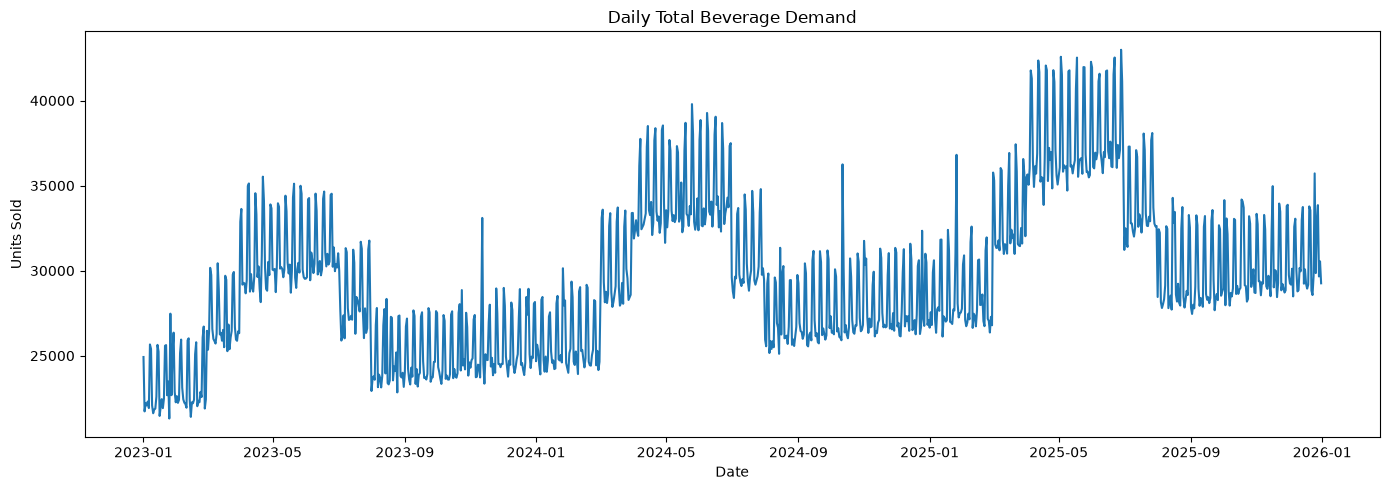

In [6]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_demand["date"],
    daily_demand["units_sold"]
)

plt.title("Daily Total Beverage Demand")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()

In [7]:
monthly_demand = (
    sales.groupby(
        sales["date"].dt.to_period("M")
    )["units_sold"]
    .sum()
    .reset_index()
)

monthly_demand["date"] = monthly_demand["date"].dt.to_timestamp()

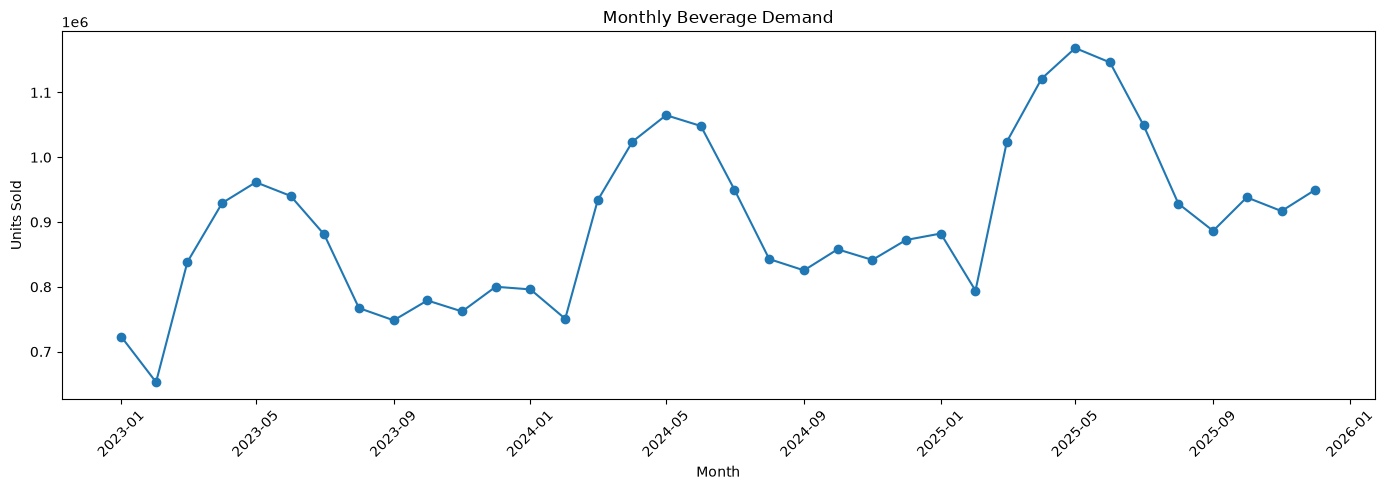

In [8]:
plt.figure(figsize=(14, 5))

plt.plot(
    monthly_demand["date"],
    monthly_demand["units_sold"],
    marker="o"
)

plt.title("Monthly Beverage Demand")
plt.xlabel("Month")
plt.ylabel("Units Sold")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [9]:
sku_demand = (
    sales.groupby(["sku", "product"])["units_sold"]
    .sum()
    .reset_index()
    .sort_values("units_sold", ascending=False)
)

sku_demand

,sku,product,units_sold
9,WT1000,Bharat Water,5331006
2,BB500,Bharat Cola,4948371
6,LM500,Lemon Blast,3806359
1,BB250,Bharat Cola,3436716
8,OR500,Orange Rush,3203167
0,BB1000,Bharat Cola,3054882
5,LM250,Lemon Blast,2677824
7,OR1000,Orange Rush,2285839
3,EN250,Energy Max,2129524
4,EN500,Energy Max,1522175


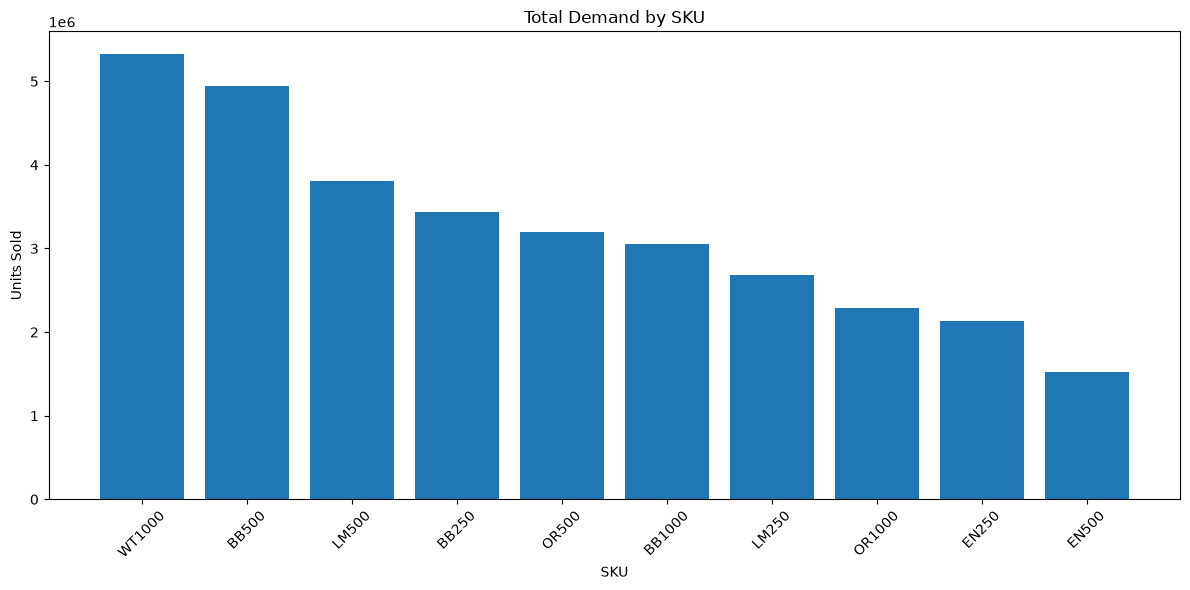

In [10]:
plt.figure(figsize=(12, 6))

plt.bar(
    sku_demand["sku"],
    sku_demand["units_sold"]
)

plt.title("Total Demand by SKU")
plt.xlabel("SKU")
plt.ylabel("Units Sold")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [11]:
regional_demand = (
    sales.groupby("region")["units_sold"]
    .sum()
    .sort_values(ascending=False)
)

regional_demand

region
West       7331744
South      6974729
North      6353667
East       6032886
Central    5702837
Name: units_sold, dtype: int64

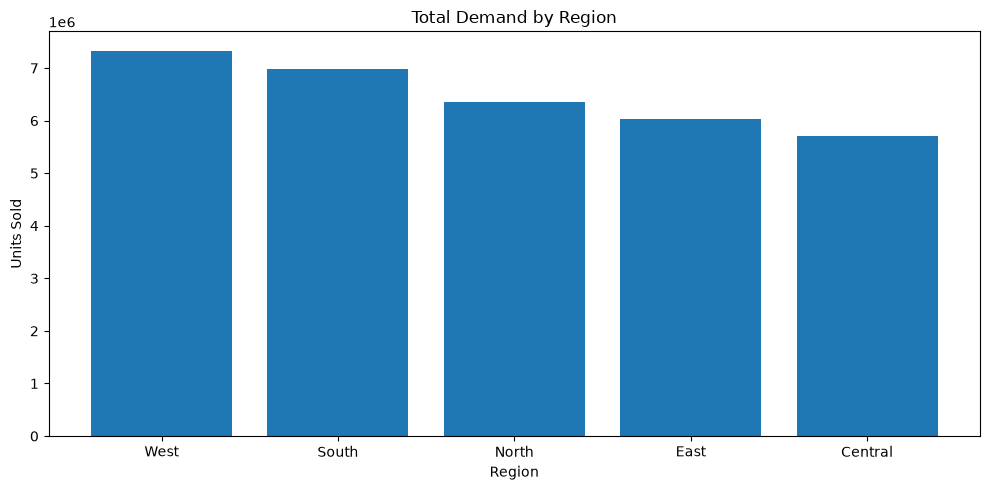

In [12]:
plt.figure(figsize=(10, 5))

plt.bar(
    regional_demand.index,
    regional_demand.values
)

plt.title("Total Demand by Region")
plt.xlabel("Region")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()

In [13]:
promotion_analysis = (
    sales.groupby("promotion")["units_sold"]
    .agg(["mean", "median", "sum", "count"])
)

promotion_analysis

,mean,median,sum,count
promotion,,,,
0,579.637084,537.0,29253704,50469
1,725.504272,667.0,3142159,4331


In [14]:
normal_demand = sales.loc[
    sales["promotion"] == 0,
    "units_sold"
].mean()

promo_demand = sales.loc[
    sales["promotion"] == 1,
    "units_sold"
].mean()

print("Average normal demand:", round(normal_demand, 2))
print("Average promotional demand:", round(promo_demand, 2))

print(
    "Promotion uplift:",
    round((promo_demand / normal_demand - 1) * 100, 2),
    "%"
)

Average normal demand: 579.64
Average promotional demand: 725.5
Promotion uplift: 25.17 %


In [15]:
weekend_analysis = (
    sales.groupby("is_weekend")["units_sold"]
    .mean()
)

print(weekend_analysis)

is_weekend
0    567.182171
1    651.161725
Name: units_sold, dtype: float64


In [16]:
weekday = weekend_analysis.loc[0]
weekend = weekend_analysis.loc[1]

print(
    "Weekend uplift:",
    round((weekend / weekday - 1) * 100, 2),
    "%"
)

Weekend uplift: 14.81 %


In [18]:
holiday_analysis = (
    sales.groupby("is_holiday")["units_sold"]
    .agg(["mean", "median", "count"])
)

holiday_analysis

,mean,median,count
is_holiday,,,
0,590.428751,546.0,54050
1,644.252000,602.0,750


In [19]:
normal = sales.loc[
    sales["is_holiday"] == 0,
    "units_sold"
].mean()

holiday = sales.loc[
    sales["is_holiday"] == 1,
    "units_sold"
].mean()

print(
    "Holiday uplift:",
    round((holiday / normal - 1) * 100, 2),
    "%"
)

Holiday uplift: 9.12 %


In [20]:
monthly_seasonality = (
    sales.groupby("month")["units_sold"]
    .mean()
)

monthly_seasonality

month
1     516.392473
2     517.116471
3     601.344086
4     683.297333
5     687.082796
6     696.659333
7     619.312473
8     545.906667
9     546.688667
10    553.758495
11    560.102222
12    563.892043
Name: units_sold, dtype: float64

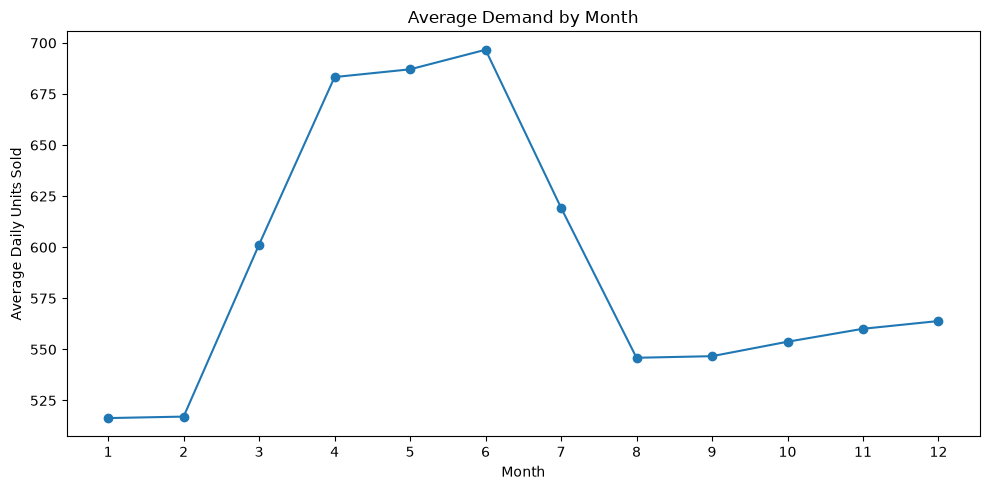

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_seasonality.index,
    monthly_seasonality.values,
    marker="o"
)

plt.title("Average Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Units Sold")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [22]:
sku_region = pd.pivot_table(
    sales,
    values="units_sold",
    index="sku",
    columns="region",
    aggfunc="sum"
)

sku_region

region,Central,East,North,South,West
sku,,,,,
BB1000,537958,566665,602372,659080,688807
BB250,602953,640347,672526,739969,780921
BB500,867460,925313,976234,1062547,1116817
EN250,376161,395876,417784,458089,481614
EN500,268703,283866,299566,328436,341604
LM250,472536,499639,522329,575586,607734
LM500,672398,707914,742055,820561,863431
OR1000,403659,424301,448154,494922,514803
OR500,561398,596933,625724,692657,726455


In [23]:
demand_variability = (
    sales.groupby("sku")["units_sold"]
    .agg(
        average_demand="mean",
        std_demand="std",
        minimum="min",
        maximum="max"
    )
)

demand_variability["coefficient_of_variation"] = (
    demand_variability["std_demand"]
    / demand_variability["average_demand"]
)

demand_variability

,average_demand,std_demand,minimum,maximum,coefficient_of_variation
sku,,,,,
BB1000,557.460219,119.805191,288,1257,0.214913
BB250,627.137956,135.353031,310,1279,0.215827
BB500,902.987409,191.349148,411,1796,0.211907
EN250,388.599270,83.765473,186,767,0.215557
EN500,277.769161,58.132146,143,532,0.209282
LM250,488.654015,105.032228,220,1045,0.214942
LM500,694.591058,147.106994,345,1534,0.211789
OR1000,417.123905,88.759761,202,956,0.212790
OR500,584.519526,125.808901,302,1192,0.215235


In [25]:
forecast_data = (
    sales.groupby(
        ["date", "sku", "region"],
        as_index=False
    )
    .agg(
        units_sold=("units_sold", "sum"),
        price=("price", "mean"),
        promotion=("promotion", "max"),
        is_holiday=("is_holiday", "max")
    )
)

forecast_data.head()

,date,sku,region,units_sold,price,promotion,is_holiday
0,2023-01-01,BB1000,Central,432,55.0,0,0
1,2023-01-01,BB1000,East,422,55.0,0,0
2,2023-01-01,BB1000,North,429,55.0,0,0
3,2023-01-01,BB1000,South,498,55.0,0,0
4,2023-01-01,BB1000,West,548,55.0,0,0


In [26]:
forecast_data["year"] = forecast_data["date"].dt.year
forecast_data["month"] = forecast_data["date"].dt.month
forecast_data["week"] = (
    forecast_data["date"]
    .dt.isocalendar()
    .week
    .astype(int)
)

forecast_data["day_of_week"] = (
    forecast_data["date"]
    .dt.dayofweek
)

forecast_data["day_of_year"] = (
    forecast_data["date"]
    .dt.dayofyear
)

forecast_data["is_weekend"] = (
    forecast_data["day_of_week"] >= 5
).astype(int)

In [27]:
forecast_data = forecast_data.sort_values(
    ["sku", "region", "date"]
)

grouped = forecast_data.groupby(
    ["sku", "region"]
)

forecast_data["lag_1"] = grouped["units_sold"].shift(1)
forecast_data["lag_7"] = grouped["units_sold"].shift(7)
forecast_data["lag_14"] = grouped["units_sold"].shift(14)
forecast_data["lag_28"] = grouped["units_sold"].shift(28)

In [28]:
forecast_data["rolling_mean_7"] = (
    grouped["units_sold"]
    .transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
)

forecast_data["rolling_mean_14"] = (
    grouped["units_sold"]
    .transform(
        lambda x: x.shift(1).rolling(14).mean()
    )
)

forecast_data["rolling_mean_28"] = (
    grouped["units_sold"]
    .transform(
        lambda x: x.shift(1).rolling(28).mean()
    )
)

forecast_data["rolling_std_28"] = (
    grouped["units_sold"]
    .transform(
        lambda x: x.shift(1).rolling(28).std()
    )
)

In [29]:
forecast_data = forecast_data.dropna().reset_index(drop=True)
print(forecast_data.shape)
print(forecast_data.isnull().sum())

(53400, 21)
date               0
sku                0
region             0
units_sold         0
price              0
promotion          0
is_holiday         0
year               0
month              0
week               0
day_of_week        0
day_of_year        0
is_weekend         0
lag_1              0
lag_7              0
lag_14             0
lag_28             0
rolling_mean_7     0
rolling_mean_14    0
rolling_mean_28    0
rolling_std_28     0
dtype: int64


In [31]:
forecast_data.to_csv(
    "../data/processed/forecast_dataset.csv",
    index=False
)